torch vision module for computer vision


In [3]:
import torch
from torch import nn

import torchvision

from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
print(torch.__version__)
print(torchvision.__version__)

2.3.1+cu121
0.18.1+cu121


In [4]:
train_data=datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 26421880/26421880 [00:16<00:00, 1615958.58it/s]


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 207108.71it/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:01<00:00, 3817716.77it/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 5257432.92it/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



In [5]:
train_data,test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [6]:
len(train_data),len(test_data)

(60000, 10000)

In [7]:
image,label=train_data[2]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0863, 0.4627, 0.0941, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.1882, 0.3451, 0.0196, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0471, 0.3922, 0.8314, 0.8039, 0.7255, 0.7020, 0.6784, 0.7294,
           0.7569, 0.8667, 0.5569, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.3333, 0.2980, 0.7804, 0.8824, 0.9725, 1.0000, 0.9333,
           0.8863, 0.6157, 0.2667, 0.3137, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.3569, 0.2706, 0.3569, 0.7882, 0.8549, 0.8824, 0.8196,
           0.6196, 0.2392, 0.3647, 0.2824, 

it gives in C H W whereas others can be in H W C


In [8]:
class_names=train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [9]:
class_to_idx=train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [10]:
image.shape

torch.Size([1, 28, 28])

In [11]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [12]:
print(f"image shape : {image.shape} C H W ")
print(f"image label : {class_names}")

image shape : torch.Size([1, 28, 28]) C H W 
image label : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [13]:
len(train_data.data), len(train_data.targets), len(test_data.data) , len(test_data.targets)

(60000, 60000, 10000, 10000)

In [14]:
class_names= train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Text(0.5, 1.0, '0')

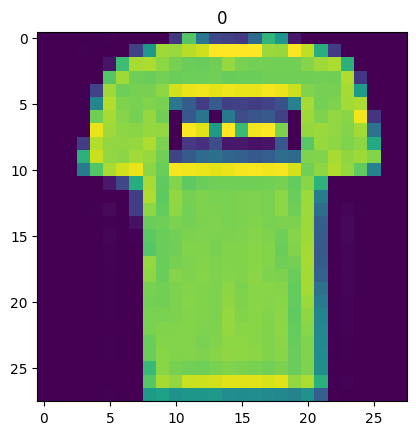

In [15]:
import matplotlib.pyplot as plt
image,label=train_data[1]
plt.imshow(image.squeeze())
plt.title(label)

Text(0.5, 1.0, '9')

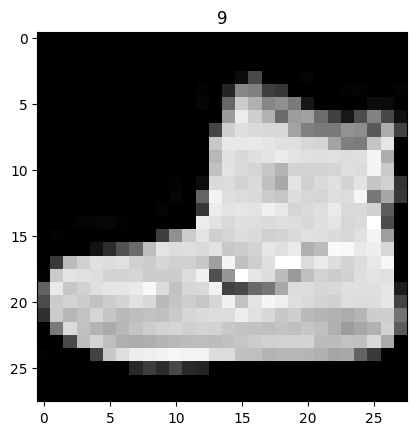

In [16]:
import matplotlib.pyplot as plt
image,label=train_data[0]
plt.imshow(image.squeeze(),cmap='gray')
plt.title(label)

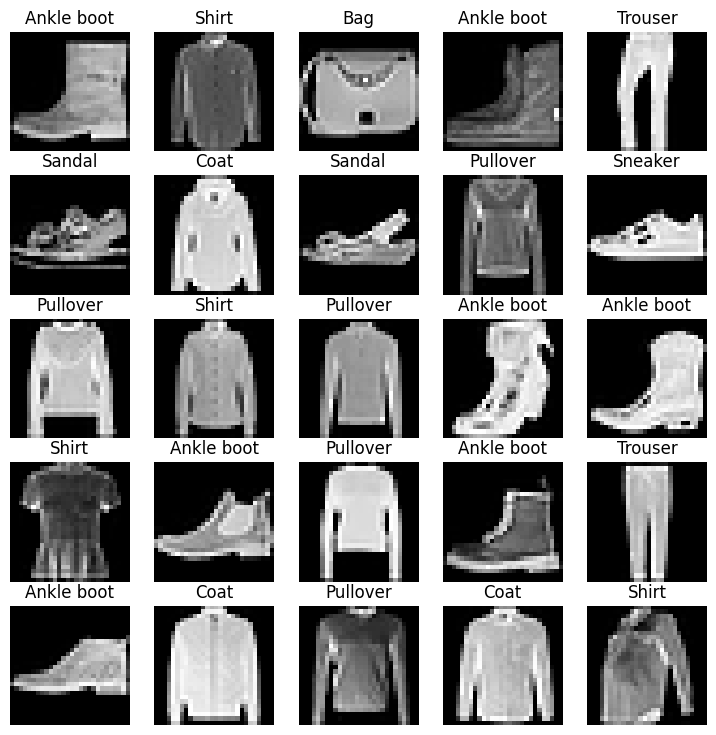

In [17]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows,cols = 5,5
for i in range(1,rows * cols + 1):
  random_idx = torch.randint(0,len(train_data),size=[1]).item()
  img,label = train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.squeeze(),cmap='gray')
  plt.title(class_names[label])
  plt.axis(False);

In [18]:
from torch.utils.data import DataLoader
batches=32
train_dataloader = DataLoader(train_data,batch_size=batches,shuffle=True)

test_dataloader = DataLoader(test_data,batch_size=batches,shuffle = False)

print(f"lenght of train dataloder : {len(train_dataloader)} batches of {batches}")
print(f"lenght of test dataloder : {len(test_dataloader)} batches of {batches}")

lenght of train dataloder : 1875 batches of 32
lenght of test dataloder : 313 batches of 32


In [19]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

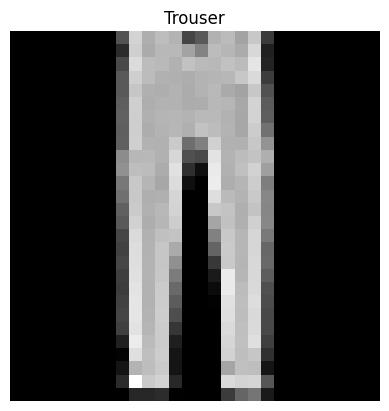

In [20]:
torch.manual_seed(42)
random_idx = torch.randint(0,len(train_features_batch),size=[1]).item()
img,label = train_features_batch[random_idx],train_labels_batch[random_idx]
plt.imshow(img.squeeze(),cmap='gray')
plt.title(class_names[label])
plt.axis(False);

In [21]:
flatten_model = nn.Flatten()
x = train_features_batch[0]
output = flatten_model(x)

print(output.shape)

torch.Size([1, 784])


In [22]:
from torch import nn
class fashionmodel0(nn.Module):
  def __init__(self,input_shape:int,hidden_inputs:int,output_shape: int):
    super().__init__()
    self.layer_stack=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_inputs),
        nn.Linear(in_features=hidden_inputs,out_features=output_shape)
    )


  def forward(self,x):
    return self.layer_stack(x)


In [23]:
torch.manual_seed(42)

model0=fashionmodel0(input_shape=784,hidden_inputs=10,output_shape=len(class_names))

model0.to("cpu")


fashionmodel0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [24]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("already there")

else :
  print("is downloading")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)

is downloading


In [25]:
from helper_functions import accuracy_fn

loss_fn=nn.CrossEntropyLoss()
opt = torch.optim.SGD(params=model0.parameters(),lr=0.1)


In [26]:
from timeit import default_timer as timer
def print_train_time(start:float,end:float,device:torch.device=None):

   total_time = end - start
   print(f"train time on {device}: {total_time:.3f} seconds")
   return total_time

In [27]:
from tqdm.auto import tqdm

torch.manual_seed(42)
train_time_start_on_cpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"epoch : {epoch}\n------")

  train_loss = 0

  for batch, (x,y) in enumerate(train_dataloader):
    model0.train()

    y_pred = model0(x)

    loss = loss_fn(y_pred,y)
    train_loss += loss

    opt.zero_grad()

    loss.backward()

    opt.step()

    if batch % 400 == 0 :
      print (f"looked at {batch * len(x)}/{len(train_dataloader.dataset)} samples")


train_loss /= len(train_dataloader)

test_loss , test_acc = 0,0
model0.eval()

with torch.inference_mode():
  for x , y in test_dataloader:
    test_pred = model0(x)
    test_loss += loss_fn(test_pred,y)

    test_acc += accuracy_fn(y_true=y,y_pred=test_pred.argmax(dim=1))

  test_loss /= len(test_dataloader)

  test_acc /= len(test_dataloader)

print (f"\n train loss : {train_loss:.5f} | test_loss : {test_loss:.5f}, test acc: {test_acc:.2f}%\n")

train_time_end_on_cpu=timer()

total_train_time_model0=print_train_time(start=train_time_start_on_cpu,end=train_time_end_on_cpu,device=str(next(model0.parameters()).device))


  0%|          | 0/3 [00:00<?, ?it/s]

epoch : 0
------
looked at 0/60000 samples
looked at 12800/60000 samples
looked at 25600/60000 samples
looked at 38400/60000 samples
looked at 51200/60000 samples
epoch : 1
------
looked at 0/60000 samples
looked at 12800/60000 samples
looked at 25600/60000 samples
looked at 38400/60000 samples
looked at 51200/60000 samples
epoch : 2
------
looked at 0/60000 samples
looked at 12800/60000 samples
looked at 25600/60000 samples
looked at 38400/60000 samples
looked at 51200/60000 samples

 train loss : 0.45325 | test_loss : 0.51088, test acc: 82.38%

train time on cpu: 26.303 seconds


In [28]:
len(test_dataloader)


313

In [41]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,):

    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for x, y in data_loader:

            y_pred = model(x)


            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y,
                                y_pred=y_pred.argmax(dim=1))


        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc}


model_0_results = eval_model(model=model0, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
)
model_0_results


{'model_name': 'fashionmodel0',
 'model_loss': 0.5108762979507446,
 'model_acc': 82.37819488817891}

first model done only linear accuracy of 83%

In [30]:
import torch

device  = "cuda" if torch.cuda.is_available else "cpu"
device

'cuda'

In [31]:

class fashionmodel1(nn.Module):
  def __init__(self,input_shape:int,hidden_inputs:int,output_shape: int):
    super().__init__()
    self.layer_stack=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_inputs),
        nn.ReLU(),
        nn.Linear(in_features=hidden_inputs,out_features=output_shape),
        nn.ReLU()
    )


  def forward(self,x:torch.Tensor):
    return self.layer_stack(x)

In [32]:
torch.manual_seed(42)

model1=fashionmodel1(input_shape=784,hidden_inputs=10,output_shape=len(class_names)).to(device)
next(model1.parameters()).device

device(type='cuda', index=0)

In [33]:
from helper_functions import accuracy_fn

loss_fn=nn.CrossEntropyLoss()
opt = torch.optim.SGD(params=model1.parameters(),lr=0.1)

In [34]:
def train_step(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               opt:torch.optim.Optimizer,
               accuracy_fn,
               device:torch.device=device):
  train_loss,train_acc = 0,0
  model.to(device)
  for batch,(x,y) in enumerate(data_loader):
    x,y = x.to(device), y.to(device)

    y_pred=model(x)

    loss = loss_fn(y_pred,y)
    train_loss += loss
    train_acc += accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))

    opt.zero_grad()

    loss.backward()

    opt.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"train loss : {train_loss:.2f} | train accuracy : {train_acc:.2f}%")

def test_step(data_loader:torch.utils.data.DataLoader,
              model:torch.nn.Module,
              loss_fn:torch.nn.Module,
              accuracy_fn,
              device:torch.device=device):
  test_loss,test_acc = 0,0
  model.to(device)
  model.eval()

  with torch.inference_mode():
    for x,y in data_loader:
      x,y = x.to(device),y.to(device)
      test_pred=model(x)
      test_loss += loss
      test_acc += accuracy_fn(y_true=y,y_pred=test_pred.argmax(dim=1))


    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"test loss : {test_loss:.2f} | test accuracy : {test_acc:.2f}%")

In [45]:
torch.manual_seed(42)

from timeit import default_timer as timer
train_time_start_on_cpu=timer()

epochs=6

for epoch in tqdm(range(epochs)):
  print(f"epoch: {epoch}\n-----")
  train_step(data_loader=train_dataloader,
             model=model1,
             loss_fn=loss_fn,
             opt=opt,
             accuracy_fn=accuracy_fn)

  test_step(data_loader=test_dataloader,
            model=model1,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn)

train_time_end_on_cpu=timer()

total_train_time_model1=print_train_time(start=train_time_start_on_cpu,
                                         end=train_time_end_on_cpu,
                                         device=device)


  0%|          | 0/6 [00:00<?, ?it/s]

epoch: 0
-----
train loss : 0.62 | train accuracy : 77.39%
test loss : 0.34 | test accuracy : 76.18%
epoch: 1
-----
train loss : 0.61 | train accuracy : 77.57%
test loss : 0.34 | test accuracy : 76.29%
epoch: 2
-----
train loss : 0.60 | train accuracy : 77.78%
test loss : 0.34 | test accuracy : 76.83%
epoch: 3
-----
train loss : 0.60 | train accuracy : 77.86%
test loss : 0.34 | test accuracy : 77.22%
epoch: 4
-----
train loss : 0.59 | train accuracy : 77.96%
test loss : 0.34 | test accuracy : 76.40%
epoch: 5
-----
train loss : 0.59 | train accuracy : 78.33%
test loss : 0.34 | test accuracy : 76.98%
train time on cuda: 61.852 seconds


In [46]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device:torch.device=device):

    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for x, y in data_loader:
            x,y = x.to(device),y.to(device)
            y_pred = model(x)


            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y,
                                y_pred=y_pred.argmax(dim=1))


        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc}


model_1_results = eval_model(model=model1, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn,device=device

)
model_1_results

{'model_name': 'fashionmodel1',
 'model_loss': 0.6293299198150635,
 'model_acc': 76.97683706070288}

In [44]:
model_0_results

{'model_name': 'fashionmodel0',
 'model_loss': 0.5108762979507446,
 'model_acc': 82.37819488817891}